# Chapter 4 - Groupby and Aggregate

https://tutswiki.com/pandas-cookbook/chapter4/

In [1]:
import pandas as pd

In [36]:
df = pd.read_csv('bikes.csv', sep=';', encoding='latin1', dayfirst=True, parse_dates=['Date'], index_col='Date')
df

,Berri 1,Br?beuf (donn?es non disponibles),C?te-Sainte-Catherine,Maisonneuve 1,Maisonneuve 2,du Parc,Pierre-Dupuy,Rachel1,St-Urbain (donn?es non disponibles)
Date,,,,,,,,,
2012-01-01,35,NaN,0,38,51,26,10,16,NaN
2012-01-02,83,NaN,1,68,153,53,6,43,NaN
2012-01-03,135,NaN,2,104,248,89,3,58,NaN
2012-01-04,144,NaN,1,116,318,111,8,61,NaN
2012-01-05,197,NaN,2,124,330,97,13,95,NaN
...,...,...,...,...,...,...,...,...,...
2012-11-01,2405,NaN,1208,1701,3082,2076,165,2461,NaN
2012-11-02,1582,NaN,737,1109,2277,1392,97,1888,NaN
2012-11-03,844,NaN,380,612,1137,713,105,1302,NaN


<Axes: xlabel='Date'>

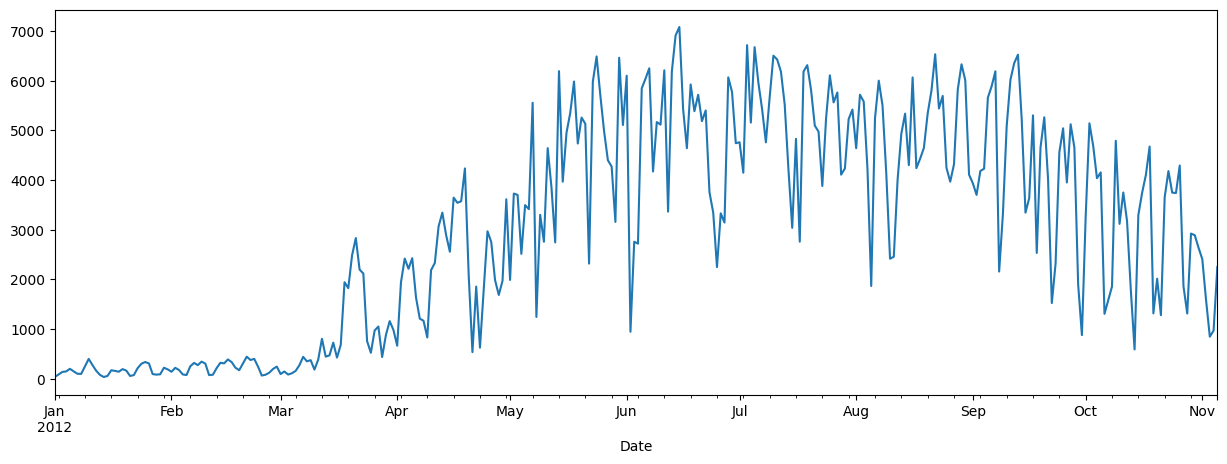

In [25]:
df['Berri 1'].plot(figsize=(15,5))

In [37]:
berri_bikes = df['Berri 1'].copy()

In [45]:
berri_bikes.index

DatetimeIndex(['2012-01-01', '2012-01-02', '2012-01-03', '2012-01-04',
               '2012-01-05', '2012-01-06', '2012-01-07', '2012-01-08',
               '2012-01-09', '2012-01-10',
               ...
               '2012-10-27', '2012-10-28', '2012-10-29', '2012-10-30',
               '2012-10-31', '2012-11-01', '2012-11-02', '2012-11-03',
               '2012-11-04', '2012-11-05'],
              dtype='datetime64[us]', name='Date', length=310, freq=None)

In [44]:
berri_bikes.index.day

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       ...
       27, 28, 29, 30, 31,  1,  2,  3,  4,  5],
      dtype='int32', name='Date', length=310)

In [43]:
berri_bikes.index.weekday

Index([6, 0, 1, 2, 3, 4, 5, 6, 0, 1,
       ...
       5, 6, 0, 1, 2, 3, 4, 5, 6, 0],
      dtype='int32', name='Date', length=310)

In [46]:
berri_bikes

Date
2012-01-01      35
2012-01-02      83
2012-01-03     135
2012-01-04     144
2012-01-05     197
              ... 
2012-11-01    2405
2012-11-02    1582
2012-11-03     844
2012-11-04     966
2012-11-05    2247
Name: Berri 1, Length: 310, dtype: int64

In [47]:
type(berri_bikes)

pandas.Series

In [48]:
berri_bikes = berri_bikes.to_frame(name='Berri 1')

In [49]:
berri_bikes

,Berri 1
Date,
2012-01-01,35
2012-01-02,83
2012-01-03,135
2012-01-04,144
2012-01-05,197
...,...
2012-11-01,2405
2012-11-02,1582
2012-11-03,844


In [50]:
berri_bikes['weekday'] = berri_bikes.index.dayofweek

In [51]:
berri_bikes

,Berri 1,weekday
Date,,
2012-01-01,35,6
2012-01-02,83,0
2012-01-03,135,1
2012-01-04,144,2
2012-01-05,197,3
...,...,...
2012-11-01,2405,3
2012-11-02,1582,4
2012-11-03,844,5


In [52]:
berri_bikes.reset_index()

,Date,Berri 1,weekday
0,2012-01-01,35,6
1,2012-01-02,83,0
2,2012-01-03,135,1
3,2012-01-04,144,2
4,2012-01-05,197,3
...,...,...,...
305,2012-11-01,2405,3
306,2012-11-02,1582,4
307,2012-11-03,844,5
308,2012-11-04,966,6


In [53]:
berri_bikes.rename(columns={'index': 'Date'}, inplace=True)

In [54]:
berri_bikes

,Berri 1,weekday
Date,,
2012-01-01,35,6
2012-01-02,83,0
2012-01-03,135,1
2012-01-04,144,2
2012-01-05,197,3
...,...,...
2012-11-01,2405,3
2012-11-02,1582,4
2012-11-03,844,5


In [57]:
weekday_counts = berri_bikes.groupby('weekday').sum()

,Berri 1
weekday,
0,134298
1,135305
2,152972
3,160131
4,141771
5,101578
6,99310


In [58]:
weekday_counts.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [59]:
weekday_counts

,Berri 1
Monday,134298
Tuesday,135305
Wednesday,152972
Thursday,160131
Friday,141771
Saturday,101578
Sunday,99310


<Axes: >

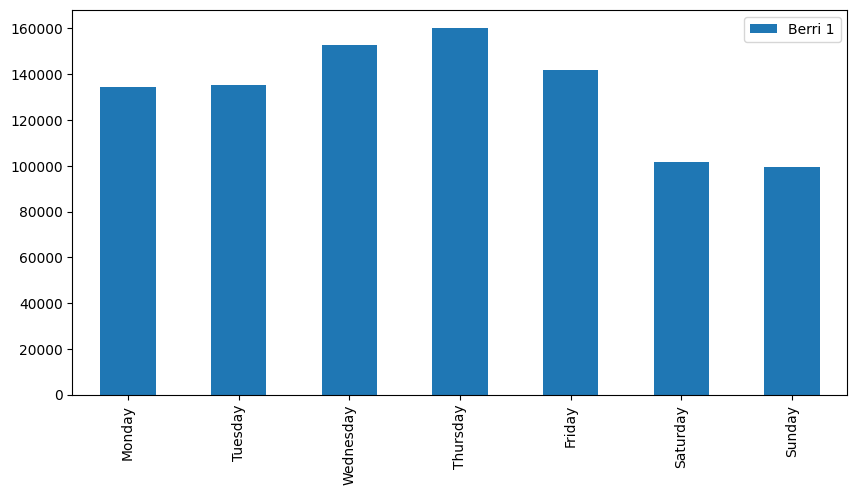

In [62]:
weekday_counts.plot(kind='bar', figsize=(10,5))